In [1]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=0,1
import os, sys
import time
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import lib
import torch, torch.nn as nn
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'

experiment_name = 'year_node_8layers'
experiment_name = '{}_{}.{:0>2d}.{:0>2d}_{:0>2d}-{:0>2d}'.format(experiment_name, *time.gmtime()[:5])
print("experiment:", experiment_name)

env: CUDA_VISIBLE_DEVICES=0,1
experiment: year_node_8layers_2026.03.20_11-10


c:\Users\Midpart\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\cuda\__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 8000). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
data = lib.Dataset("YEAR", random_state=1337, quantile_transform=True, quantile_noise=1e-3)
in_features = data.X_train.shape[1]

mu, std = data.y_train.mean(), data.y_train.std()
normalize = lambda x: ((x - mu) / std).astype(np.float32)
data.y_train, data.y_valid, data.y_test = map(normalize, [data.y_train, data.y_valid, data.y_test])

print("mean = %.5f, std = %.5f" % (mu, std))

mean = 1998.39193, std = 10.92832


In [3]:
model = nn.Sequential(
    lib.DenseBlock(in_features, 128, num_layers=8, tree_dim=3, depth=6, flatten_output=False,
                   choice_function=lib.entmax15, bin_function=lib.entmoid15),
    lib.Lambda(lambda x: x[..., 0].mean(dim=-1)),  # average first channels of every tree
    
).to(device)

with torch.no_grad():
    res = model(torch.as_tensor(data.X_train[:5000], device=device))
    # trigger data-aware init
    
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

In [4]:
from qhoptim.pyt import QHAdam
optimizer_params = { 'nus':(0.7, 1.0), 'betas':(0.95, 0.998) }

In [5]:
trainer = lib.Trainer(
    model=model, loss_function=F.mse_loss,
    experiment_name=experiment_name,
    warm_start=False,
    Optimizer=QHAdam,
    optimizer_params=optimizer_params,
    verbose=True,
    n_last_checkpoints=5
)

In [6]:
from tqdm import tqdm
from IPython.display import clear_output
loss_history, mse_history = [], []
best_mse = float('inf')
best_step_mse = 0
early_stopping_rounds = 5000
report_frequency = 100

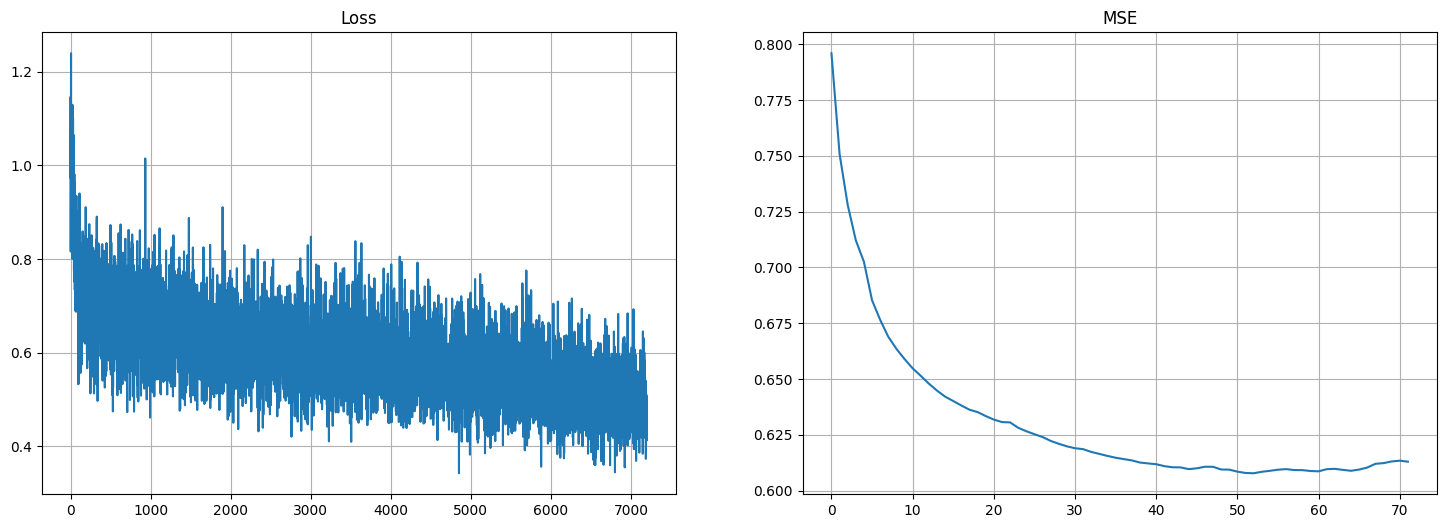

Loss 0.45742
Val MSE: 0.61299


In [7]:
# for batch in lib.iterate_minibatches(data.X_train, data.y_train, batch_size=1024, 
#                                                 shuffle=True, epochs=float('inf')):
#     metrics = trainer.train_on_batch(*batch, device=device)
    
#     loss_history.append(metrics['loss'])

#     if trainer.step % report_frequency == 0:
#         trainer.save_checkpoint()
#         trainer.average_checkpoints(out_tag='avg')
#         trainer.load_checkpoint(tag='avg')
#         mse = trainer.evaluate_mse(
#             data.X_valid, data.y_valid, device=device, batch_size=16384)

#         if mse < best_mse:
#             best_mse = mse
#             best_step_mse = trainer.step
#             trainer.save_checkpoint(tag='best_mse')
#         mse_history.append(mse)
        
#         trainer.load_checkpoint()  # last
#         trainer.remove_old_temp_checkpoints()

#         clear_output(True)
#         plt.figure(figsize=[18, 6])
#         plt.subplot(1, 2, 1)
#         plt.plot(loss_history)
#         plt.title('Loss')
#         plt.grid()
#         plt.subplot(1, 2, 2)
#         plt.plot(mse_history)
#         plt.title('MSE')
#         plt.grid()
#         plt.show()
#         print("Loss %.5f" % (metrics['loss']))
#         print("Val MSE: %0.5f" % (mse))
#     if trainer.step > best_step_mse + early_stopping_rounds:
#         print('BREAK. There is no improvment for {} steps'.format(early_stopping_rounds))
#         print("Best step: ", best_step_mse)
#         print("Best Val MSE: %0.5f" % (best_mse))
#         break
#epochs=float('inf')
epochs = 10
batch_size = 512 #1024
batch_size_mse =4096 #16384
for batch in lib.iterate_minibatches(data.X_train, data.y_train, batch_size=batch_size, shuffle=True, epochs=epochs):
    metrics = trainer.train_on_batch(*batch, device=device)
    
    # FIX: convert tensor to number
    loss_history.append(metrics['loss'].item())

    if trainer.step % report_frequency == 0:
        trainer.save_checkpoint()
        trainer.average_checkpoints(out_tag='avg')
        trainer.load_checkpoint(tag='avg')

        mse = trainer.evaluate_mse(data.X_valid, data.y_valid, device=device, batch_size=batch_size_mse)

        if mse < best_mse:
            best_mse = mse
            best_step_mse = trainer.step
            trainer.save_checkpoint(tag='best_mse')

        mse_history.append(mse)
        
        trainer.load_checkpoint()  # last
        trainer.remove_old_temp_checkpoints()

        clear_output(True)

        plt.figure(figsize=(18, 6))

        plt.subplot(1, 2, 1)
        plt.plot(loss_history)
        plt.title('Loss')
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.plot(mse_history)
        plt.title('MSE')
        plt.grid()

        plt.show()

        print("Loss %.5f" % metrics['loss'].item())
        print("Val MSE: %0.5f" % mse)

    if trainer.step > best_step_mse + early_stopping_rounds:
        print('BREAK. There is no improvement for {} steps'.format(early_stopping_rounds))
        print("Best step:", best_step_mse)
        print("Best Val MSE: %0.5f" % best_mse)
        break


In [8]:
trainer.load_checkpoint(tag='best_mse')
mse = trainer.evaluate_mse(data.X_test, data.y_test, device=device)
print('Best step: ', trainer.step)
print("Test MSE: %0.5f" % (mse))

Loaded logs/year_node_8layers_2026.03.17_14-56\checkpoint_best_mse.pth
Best step:  5300
Test MSE: 0.64074


In [9]:
mse * std ** 2

np.float64(76.52256462766576)